# 05 — Leverkusen 23/24 × Inter Miami 2023 Overlay

Loads persisted artifacts from `data/marts/` and `docs/figures/`. Does not recompute.

**Scope note.** The original Module C spec called for a Leverkusen pre/post comparison (2022/23 → 2023/24) around Alonso's arrival. Bundesliga 2022/23 is not in StatsBomb Open Data (see `docs/data_reality.md` §1 + Phase 5 appendix), so the pre/post step was dropped. Module C is now a side-by-side overlay of Leverkusen 2023/24 against Inter Miami 2023 on Module A (raw build-up failure rate) + Module B (six post-regain metrics).

**Caveat (repeat across every figure).** Associational, not causal. Cross-team, cross-league comparison on observational data. Differences reflect team, roster, schedule, and league variance — not the effect of any individual coach or player. No 'Alonso caused this.'

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
MARTS = ROOT / "data" / "marts"
FIG = ROOT / "docs" / "figures"

overlay = pd.read_csv(MARTS / "leverkusen_overlay.csv")
# Hide the caveat column for display; it's the same string on every row.
overlay.drop(columns=["caveat"])

,metric,leverkusen_mean,leverkusen_ci_lo,leverkusen_ci_hi,inter_miami_mean,inter_miami_ci_lo,inter_miami_ci_hi,diff_leverkusen_minus_miami,diff_ci_lo,diff_ci_hi,ci_excludes_zero
0,raw_buildup_failure_rate,0.205584,0.159538,0.254869,0.342466,0.253085,0.453161,-0.136882,-0.261834,-0.034565,True
1,xg_per_regain,0.017848,0.014238,0.021647,0.008271,0.004397,0.013506,0.009577,0.003216,0.015867,True
2,time_to_shot_median,5.000000,4.000000,6.000000,5.500000,4.000000,9.000000,-0.500000,-5.012500,1.500000,False
3,rushed_shot_rate,0.278125,0.220894,0.337423,0.352941,0.136364,0.484907,-0.074816,-0.211111,0.122611,False
4,regain_to_final_third_rate,0.808071,0.773879,0.841410,0.668555,0.567797,0.772196,0.139516,0.020137,0.249987,True
5,regain_to_loss_rate,0.013139,0.008314,0.018319,0.011331,0.002710,0.024465,0.001808,-0.011605,0.012789,False
6,patience_composite,-9.791874,-10.201281,-9.361016,-10.878091,-11.317429,-10.284371,1.086217,0.364795,1.799527,True


## Chart 1 — Side-by-side bar chart

Leverkusen 23/24 in cyan, Inter Miami 2023 in violet. Error bars are 95% bootstrap CIs (1000 iterations, matches resampled independently per side).

**Associational caveat.** Side-by-side bars compare two observational team-season slices (cross-league); gaps are consistent with roster, schedule, competition, and sample-size differences, not with a controlled treatment effect.

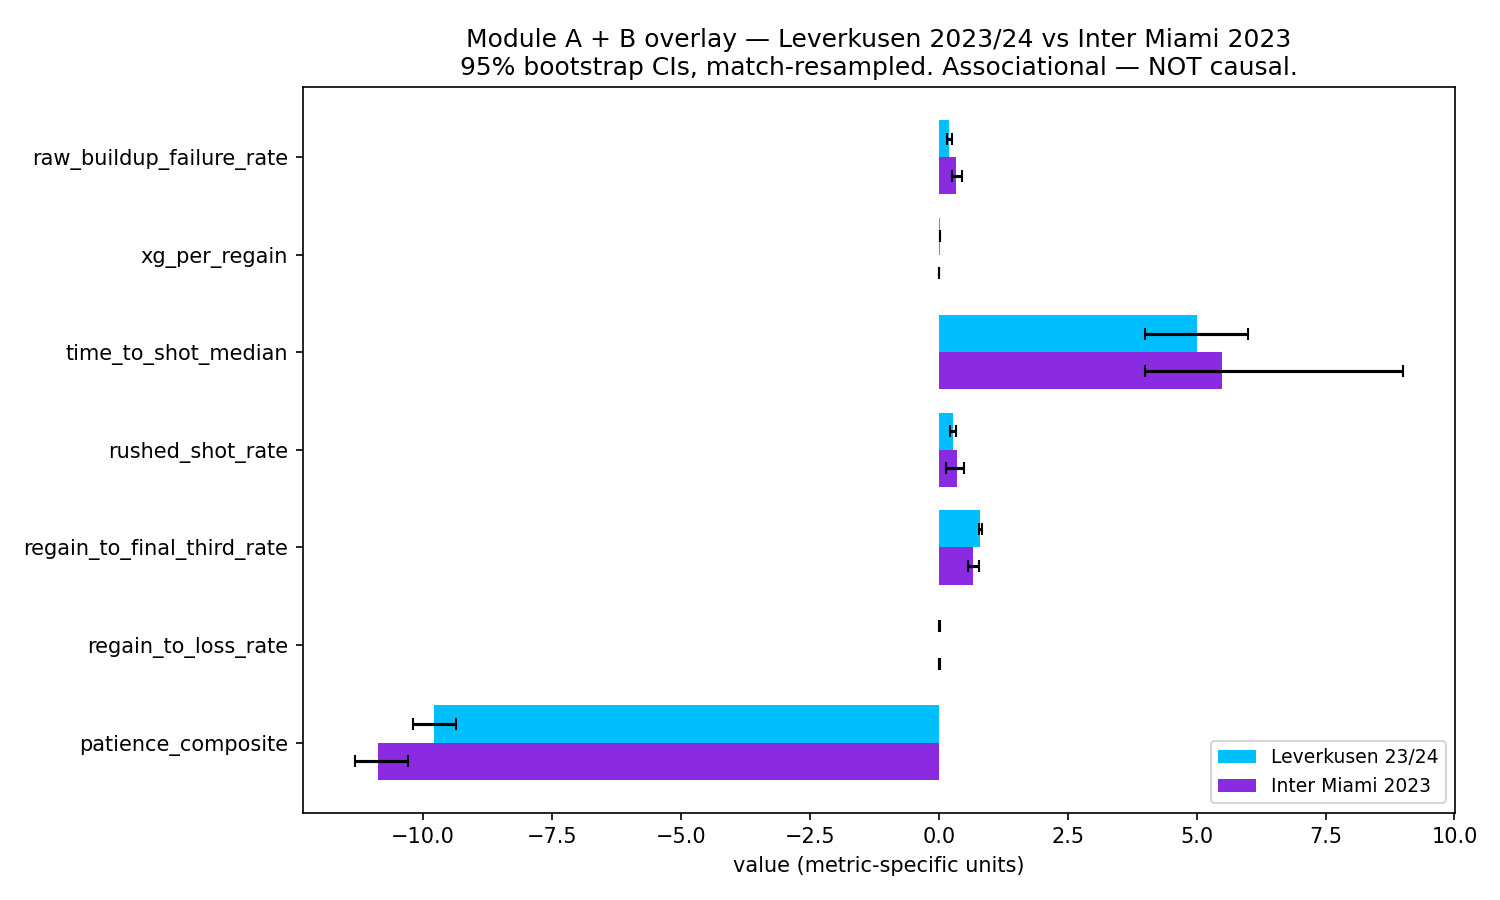

In [2]:
display(Image(str(FIG / "leverkusen_overlay_bar.png")))

**Interpretation.** Below, **every point estimate is paired with its 95% bootstrap CI** from the mart. **Leverkusen 23/24 uses 34 matches**; **Inter Miami 2023 uses 6** — **tighter Leverkusen intervals coincide with larger match count**; **Miami’s wider bands are not a comparable precision anchor** for cross-team ranking. **Raw build-up failure rate**: Leverkusen **0.206** **[0.160, 0.255]** vs Miami **0.342** **[0.253, 0.453]**. **Regain-to-final-third rate**: **0.808** **[0.774, 0.841]** vs **0.669** **[0.568, 0.772]**. **xG per regain**: **0.0178** **[0.0142, 0.0216]** vs **0.00827** **[0.00440, 0.0135]**. **Median time-to-shot**: **5.0 s** **[4.0, 6.0]** vs **5.5 s** **[4.0, 9.0]** (**overlap**). **Rushed-shot rate**: **0.278** **[0.221, 0.337]** vs **0.353** **[0.136, 0.485]** (**Miami interval wide**). **Regain-to-loss**: **0.0131** **[0.00831, 0.0183]** vs **0.0113** **[0.00271, 0.0245]**. **Patience composite**: **−9.79** **[−10.20, −9.36]** vs **−10.88** **[−11.32, −10.28]**. **Patterns are associational only** — **causal attribution across clubs is unsupported**.

## Chart 2 — Forest plot of differences (Leverkusen − Inter Miami)

Sorted by absolute magnitude. Cyan markers: 95% CI excludes zero. Gray: CI overlaps zero.

**Associational caveat.** Each difference is **Leverkusen minus Miami** on the same bootstrap; significance is **interval-based**, not a hypothesis test, and **confounding across leagues/match counts** remains unmodeled.

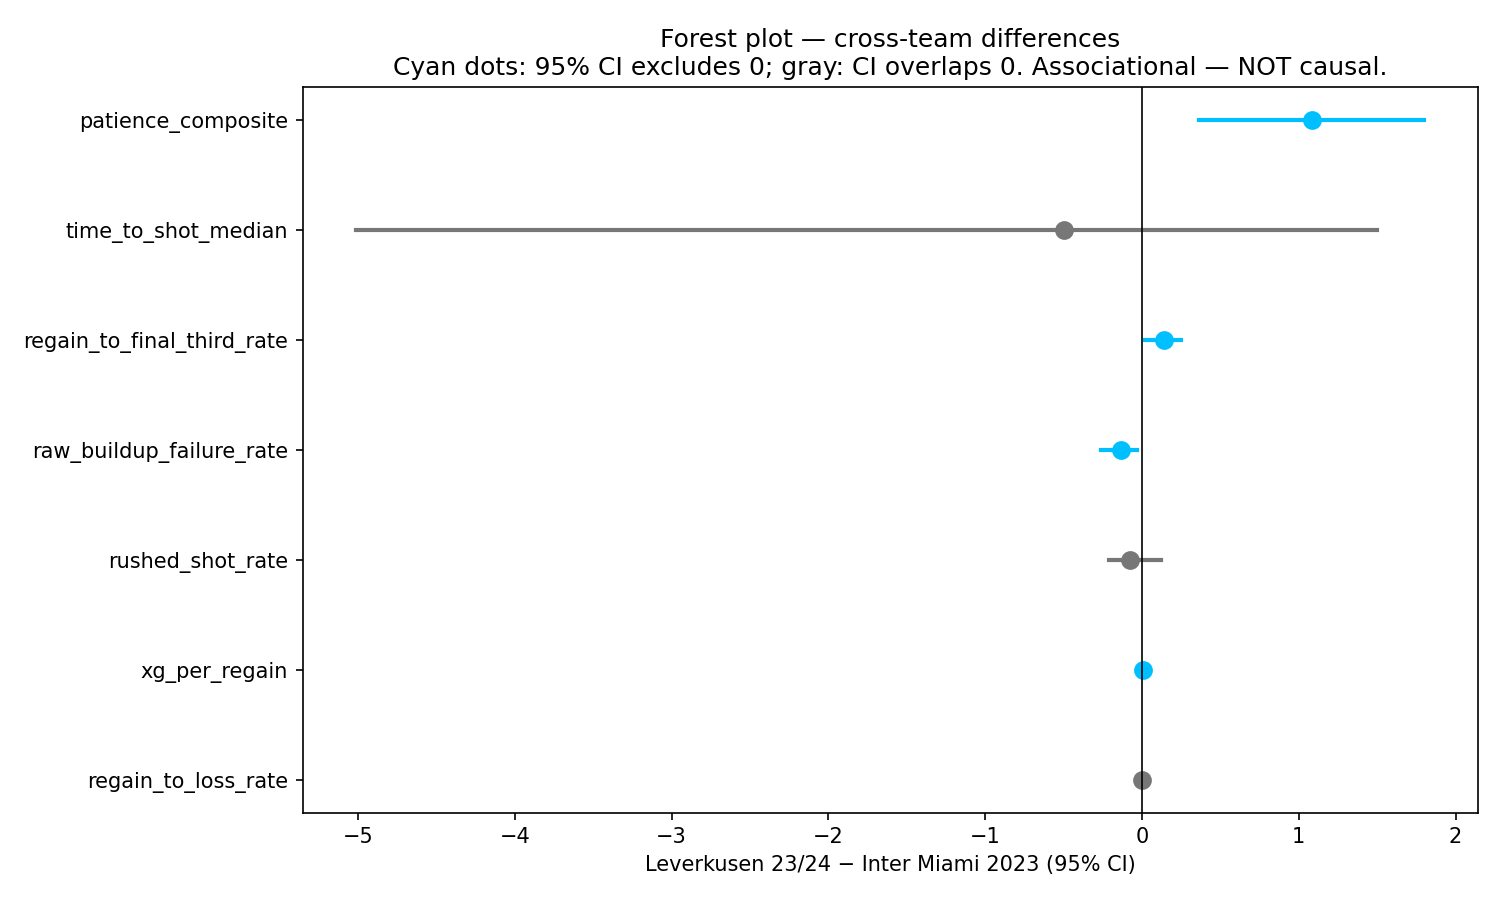

In [3]:
display(Image(str(FIG / "leverkusen_diff_forest.png")))

**Interpretation.** **Forest entries are paired differences (Leverkusen − Miami)** with **95% bootstrap CIs** from `leverkusen_overlay.csv`. **Four intervals exclude zero** — **each named with magnitude and CI**: **`patience_composite` +1.086** **[0.365, 1.800]** (**Leverkusen less negative on the Module B composite scale**); **`regain_to_final_third_rate` +0.140** **[0.020, 0.250]**; **`raw_buildup_failure_rate` −0.137** **[−0.262, −0.035]** (**Leverkusen lower**); **`xg_per_regain` +0.00958** **[0.00322, 0.0159]**. **The three largest shifts by absolute magnitude** coincide with **those composite / progression / build-up rows** (**patience**, **final-third**, **build-up failure**). **Intervals that overlap zero**: **`time_to_shot_median` −0.500 s** **[−5.01, 1.50]**; **`rushed_shot_rate` −0.0748** **[−0.211, 0.123]**; **`regain_to_loss_rate` +0.00181** **[−0.0116, 0.0128]**. **Those overlaps are consistent with noise** given **six Miami matches versus 34 Leverkusen matches** — **not interchangeable baselines**. **Causal attribution to either club or staff is unsupported**; **differences remain associational descriptors** **of two thin slices**.

## Chart 3 — Regain location hexbins, two-panel overlay

Where each team wins the ball. Attacking right; x=0 own goal, x=120 opponent goal. Dashed lines at x=40 and x=80 mark the thirds.

**Associational caveat.** Spatial intensity reflects **where regains clustered in each sample**, not optimal pressing truth; panels share geometry but **not comparability of sample depth or color scaling** (see interpretation).

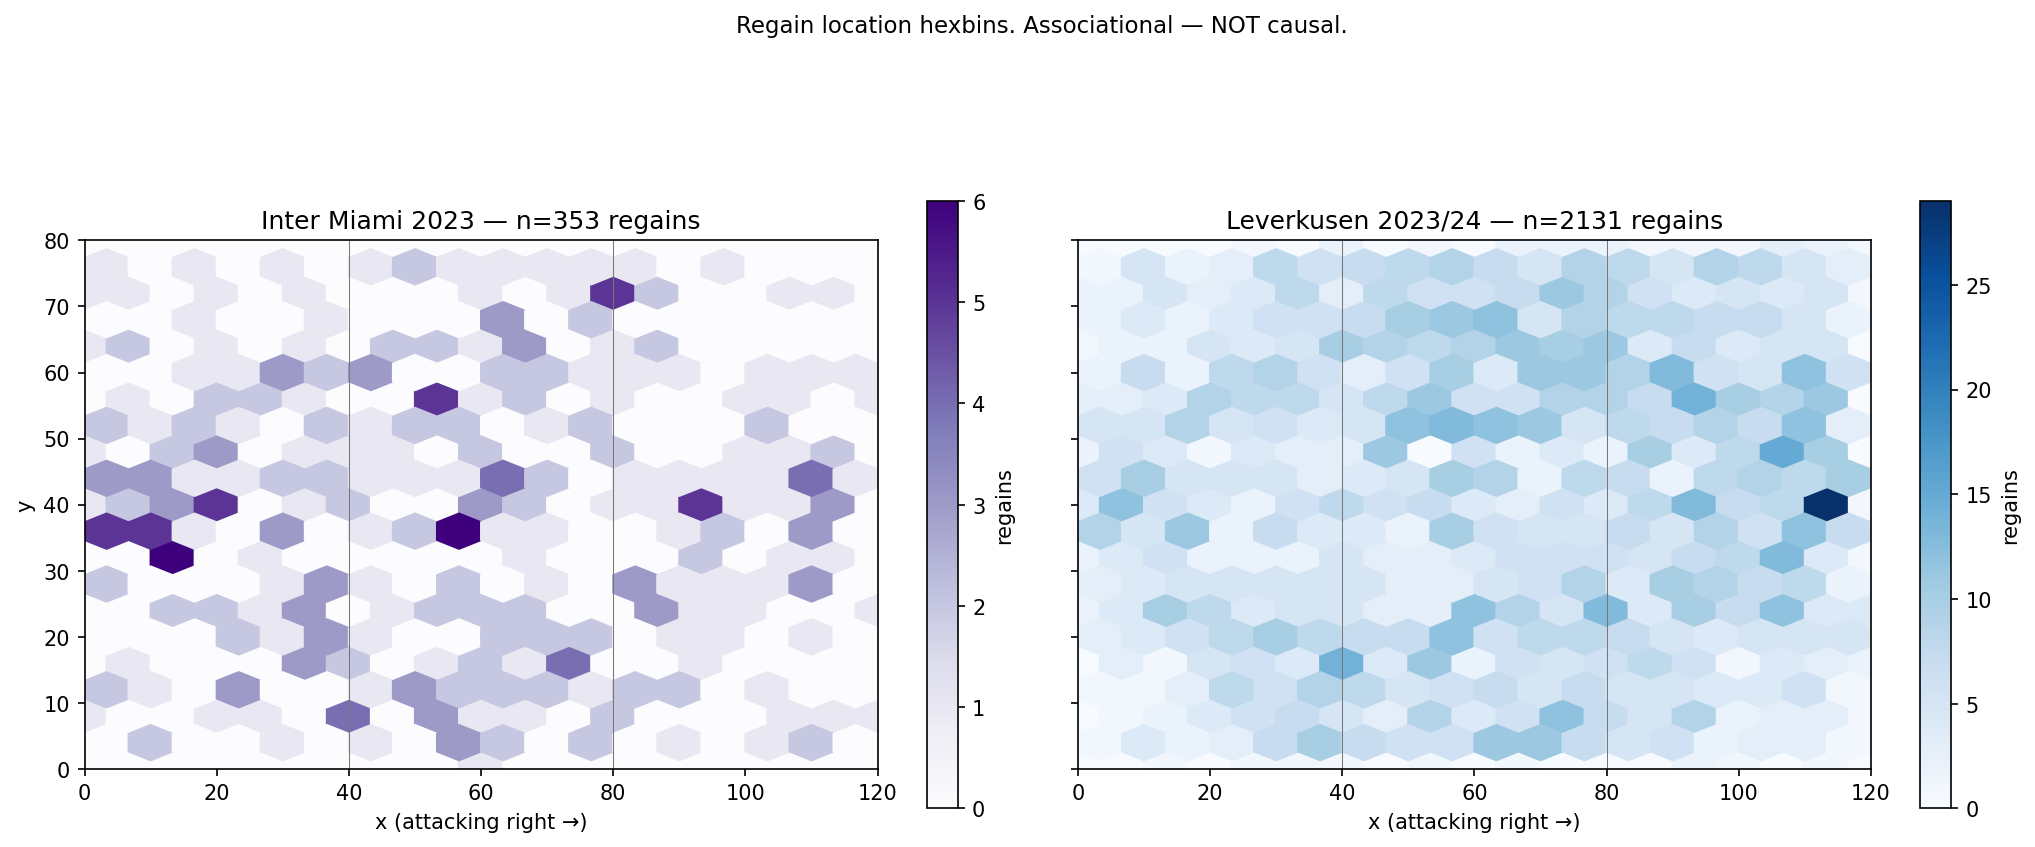

In [4]:
display(Image(str(FIG / "leverkusen_vs_miami_regain_heatmaps.png")))

**Interpretation.** **Heatmaps are descriptive**: **Leverkusen’s sample spans 34 matches (~2131 regains)** vs **Inter Miami’s six (~353)** — **Miami is a thin vertical slice**, **not a league anchor**. **Both maps place substantial regain mass between the defensive and middle thirds**, **consistent with** **mid-/deep-block recoveries rather than a pure high press** (**associational read**). **Leverkusen’s centroid reads slightly higher** — **consistent with** **the higher regain-to-final-third rate** (**Chart 2**, **difference +0.140**, **CI [0.020, 0.250]**). **Panels reuse the pitch grid but apply separate color scales** (**~6× more raw events on the left**) — **side-by-side intensity should not be read as equal statistical footing**. **Spatial similarity is insufficient to infer** **equivalent tactical identity**; **schedule and opponent mix differ**.

## Where Inter Miami 2023 sits relative to Leverkusen 2023/24

**Associational caveat.** **Overlay ordering is observational**; **language below stays descriptive**.

**Interpretation.** **On the four difference rows whose 95% CIs exclude zero** (**`raw_buildup_failure_rate`**, **`regain_to_final_third_rate`**, **`xg_per_regain`**, **`patience_composite`**), **Inter Miami’s point estimates** **line up with** **more build-up failures** (**0.342**, **CI [0.253, 0.453]**), **lower regain-to-final-third conversion** (**0.669**, **CI [0.568, 0.772]**), **lower xG per regain** (**0.00827**, **CI [0.00440, 0.0135]**), **and a more negative patience composite** (**−10.88**, **CI [−11.32, −10.28]**) **relative to Leverkusen’s** (**0.206 [0.160, 0.255]**, **0.808 [0.774, 0.841]**, **0.0178 [0.0142, 0.0216]**, **−9.79 [−10.20, −9.36]**). **That stack is consistent with** **the direction of the forest plot** (**Chart 2**), **yet it is hedged**: **Miami’s evidence is six matches**, **Leverkusen’s is 34**, **so Miami must not be treated as an equally stable counterfactual**. **Claims about coaching or roster mechanisms would require evidence beyond this notebook**. **Layer-2 prose** (**Spielverlagerung**, **The Athletic**, **Coaches' Voice**) **remains** **where plausible narrative lives**; **this notebook only records** **directional gaps with CIs on these snapshots**.

## What this suggests for the article

- **Four paired gaps (Leverkusen − Miami) exclude zero with 95% bootstrap CIs**: **`patience_composite` +1.086 [0.365, 1.800]**; **`regain_to_final_third_rate` +0.140 [0.020, 0.250]**; **`raw_buildup_failure_rate` −0.137 [−0.262, −0.035]**; **`xg_per_regain` +0.00958 [0.00322, 0.0159]** — **consistent with** **directional separation on composite scale, progression, build-up failure, and xG-per-regain** **on these observational snapshots** (**not** **an apples-to-apples league benchmark**).
- **Three paired gaps retain interval overlap at zero** (**median time-to-shot**, **rushed-shot rate**, **regain-to-loss**) — **suggesting** **those contrasts may be dominated by uncertainty**, **especially on Miami’s six-match side**.
- **Hex maps + higher regain-to-final-third estimate are consistent with** **Leverkusen recovering slightly higher while both samples stay mid-/deep-heavy** — **associational spatial read**, **not** **equivalent sample depth** (**34 matches / ~2131 regains vs 6 / ~353**).
- **Phase 8 prose should foreground scope**: **overlay replaces unavailable Leverkusen 22/23 pre/post data**; **Layer-2 outlets carry interpretive vocabulary**, **while numbers stay bounded as coincident observational contrasts with CIs**.